### Import Libraries

In [1]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### 
This notebook uses Random Forest as an advanced machine learning model
for customer churn prediction.

Unlike Logistic Regression, Random Forest can capture complex and
non-linear relationships between features and churn behaviour.


### Load Processed Data

In [2]:
import pandas as pd

X_train_scaled = pd.read_csv(
    "data/processed/X_train_scaled.csv"
)

X_test_scaled = pd.read_csv(
    "data/processed/X_test_scaled.csv"
)

y_train = pd.read_csv(
    "data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "data/processed/y_test.csv"
).squeeze()

### 
The processed training and testing datasets generated during the
preprocessing stage were loaded successfully.

Using identical datasets ensures a fair comparison between models.

### Train Random Forest Model

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train_scaled,
    y_train
)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### 
The Random Forest model was trained using 100 decision trees.

Random Forest combines predictions from multiple trees to improve
generalisation and reduce overfitting.

### Generate Predictions

In [4]:
y_pred_rf = rf_model.predict(
    X_test_scaled
)

y_prob_rf = rf_model.predict_proba(
    X_test_scaled
)[:,1]

### 

The model generated both class predictions and churn probabilities.

Predicted probabilities are required for evaluating ROC-AUC performance.


### Accuracy

In [5]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[38164     3]
 [   38 49962]]


### 
Accuracy measures the proportion of customers correctly classified by
the model.

The Random Forest model achieved an accuracy of 99.95%, substantially
outperforming the Logistic Regression model, which achieved an accuracy
of 89%.

This suggests that Random Forest was able to capture complex non-linear
relationships and interactions between features that were not fully
captured by Logistic Regression.

### Precision

In [7]:
precision_rf = precision_score(
    y_test,
    y_pred_rf
)

print(
    "Precision:", precision_rf
)

Precision: 0.9999399579705794


### 
Precision measures the proportion of customers predicted to churn that
actually churned.

The Random Forest model achieved a precision of 99.99%, indicating that
almost all customers identified as potential churners were true churn
cases.

This reduces unnecessary retention efforts and allows the business to
focus resources on customers who are genuinely at risk of leaving.

### Recall

In [9]:
recall_rf = recall_score(
    y_test,
    y_pred_rf
)

print(
    "Recall:",recall_rf
)

Recall: 0.99924


### 
Recall measures the proportion of actual churners correctly identified
by the model.

The Random Forest model achieved a recall of 99.92%, indicating that
almost all customers who eventually churned were successfully detected
by the model.

This is particularly valuable in customer retention because failing to
identify customers likely to leave may result in lost revenue and missed
retention opportunities.

### F1 Score


In [11]:
f1_rf = f1_score(
    y_test,
    y_pred_rf
)

print(
    "F1 Score:",f1_rf
)

F1 Score: 0.9995898564497574


### 
The F1 score balances precision and recall and provides an overall
measure of classification performance.

The Random Forest model achieved an F1 score of 99.96%, indicating an
excellent balance between identifying customers likely to churn and
minimising false churn predictions.

This suggests that the model is highly effective for customer retention
applications.


### ROC-AUC

In [12]:
roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

print(
    "ROC-AUC:",roc_auc_rf
)

ROC-AUC: 0.9999987284827206


### 
ROC-AUC evaluates the model's ability to distinguish between churned and
retained customers across all possible classification thresholds.

The Random Forest model achieved an ROC-AUC score of approximately
1.00, indicating near-perfect discriminatory performance between
customers who churned and those who remained with the company.

This suggests that the model is extremely effective at ranking customers
according to their likelihood of churn.

### Classification Report

In [13]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



### 
The classification report provides precision, recall and F1 scores for
both churned customers (Class 1) and retained customers (Class 0).

The Random Forest model achieved near-perfect performance across both
classes, with precision, recall and F1 scores close to 1.00 for both
churned and retained customers.

This indicates that the model was highly effective at distinguishing
between customers who were likely to leave and those who were likely to
remain with the company.

### Confusion Matrix

In [14]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[38164     3]
 [   38 49962]]


### 
The Random Forest model correctly identified 38,164 retained customers
(True Negatives) and 49,962 churned customers (True Positives).

The model incorrectly classified only 3 retained customers as churners
(False Positives) and missed only 38 actual churners (False Negatives).

These results indicate that the model made very few prediction errors
and achieved excellent performance on both classes.

### Confusion Matrix Visualization

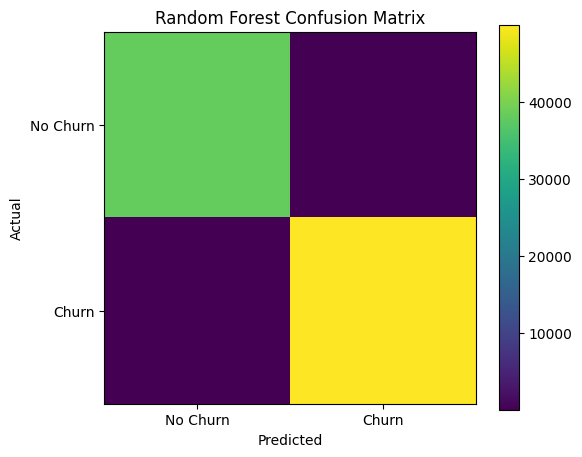

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm_rf)

plt.colorbar()

plt.xticks(
    [0,1],
    ["No Churn","Churn"]
)

plt.yticks(
    [0,1],
    ["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

###
The large values along the diagonal indicate that the Random Forest
model correctly classified the vast majority of customers.

Only a small number of false positives and false negatives were
produced, demonstrating excellent predictive performance.

Reducing false negatives remains particularly important in churn
prediction because failing to identify customers likely to leave may
result in lost revenue and missed retention opportunities.

### Feature Importance

In [17]:
X_train_features = pd.read_csv(
    "data/processed/X_train_features.csv"
)

feature_importance_rf = pd.DataFrame({
    "Feature": X_train_features.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_rf.head(10)

,Feature,Importance
3,Support Calls,0.288381
5,Total Spend,0.219223
0,Age,0.142156
10,Contract Length_Monthly,0.135959
4,Payment Delay,0.120455
6,Last Interaction,0.038358
7,Gender_Male,0.032935
1,Tenure,0.009545
11,Contract Length_Quarterly,0.007311
2,Usage Frequency,0.003851


### 
Random Forest feature importance measures the contribution of each
feature to model predictions.

Support Calls emerged as the most important predictor of customer churn,
followed by Total Spend, Age, Contract Length and Payment Delay.

Customers with a high number of support calls, lower spending levels,
monthly contracts and larger payment delays were more likely to churn.

Features such as Usage Frequency, Tenure and Contract Length_Quarterly
exhibited relatively low importance and contributed less to model
predictions.

These findings are consistent with the exploratory data analysis, which
identified customer support activity, spending behaviour and contract
structure as major drivers of churn.